In [38]:
!git clone https://github.com/Break-Through-Tech/MathWorks-1C-unlocking-embedded-ai-through-efficient-compression.git

Cloning into 'MathWorks-1C-unlocking-embedded-ai-through-efficient-compression'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 80 (delta 26), reused 43 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 19.41 MiB | 25.32 MiB/s, done.
Resolving deltas: 100% (26/26), done.


In [39]:
%cd MathWorks-1C-unlocking-embedded-ai-through-efficient-compression

/content/MathWorks-1C-unlocking-embedded-ai-through-efficient-compression/MathWorks-1C-unlocking-embedded-ai-through-efficient-compression/MathWorks-1C-unlocking-embedded-ai-through-efficient-compression


In [40]:
# ── Environment Check (using the shared loader) ─────────────
# Loads through src/data.py so the whole team reads the same
# .mat keys and the same fixed train/val/test split. Nobody
# re-implements loading, so nobody drifts.

import sys
import numpy as np
from collections import Counter

SEED = 42
np.random.seed(SEED)

# In Colab the repo is cloned into /content/<repo-name>.
repo_path = "/content/MathWorks-1C-unlocking-embedded-ai-through-efficient-compression"
if repo_path not in sys.path:
    sys.path.append(repo_path)

from src.data import load_all_splits

splits = load_all_splits(data_dir=f"{repo_path}/data")
X_train, y_train = splits["train"]
X_val,   y_val   = splits["val"]
X_test,  y_test  = splits["test"]

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Counts:", len(y_train), len(y_val), len(y_test))
print("Train class balance:", Counter(y_train))
print("Val class balance:", Counter(y_val))
print("Test class balance:", Counter(y_test))

assert X_train.shape == (393, 5000)
assert X_val.shape == (27, 5000)
assert X_test.shape == (102, 5000)
assert Counter(y_train) == Counter({
    'Normal': 131, 'InnerRaceFault': 131, 'OuterRaceFault': 131
})
print("\n\u2705 Data matches spec \u2014 environment check passed.")

Shapes: (393, 5000) (27, 5000) (102, 5000)
Counts: 393 27 102
Train class balance: Counter({np.str_('InnerRaceFault'): 131, np.str_('OuterRaceFault'): 131, np.str_('Normal'): 131})
Val class balance: Counter({np.str_('InnerRaceFault'): 9, np.str_('OuterRaceFault'): 9, np.str_('Normal'): 9})
Test class balance: Counter({np.str_('InnerRaceFault'): 34, np.str_('OuterRaceFault'): 34, np.str_('Normal'): 34})

✅ Data matches spec — environment check passed.


### Visualizing Raw Vibration Waveforms


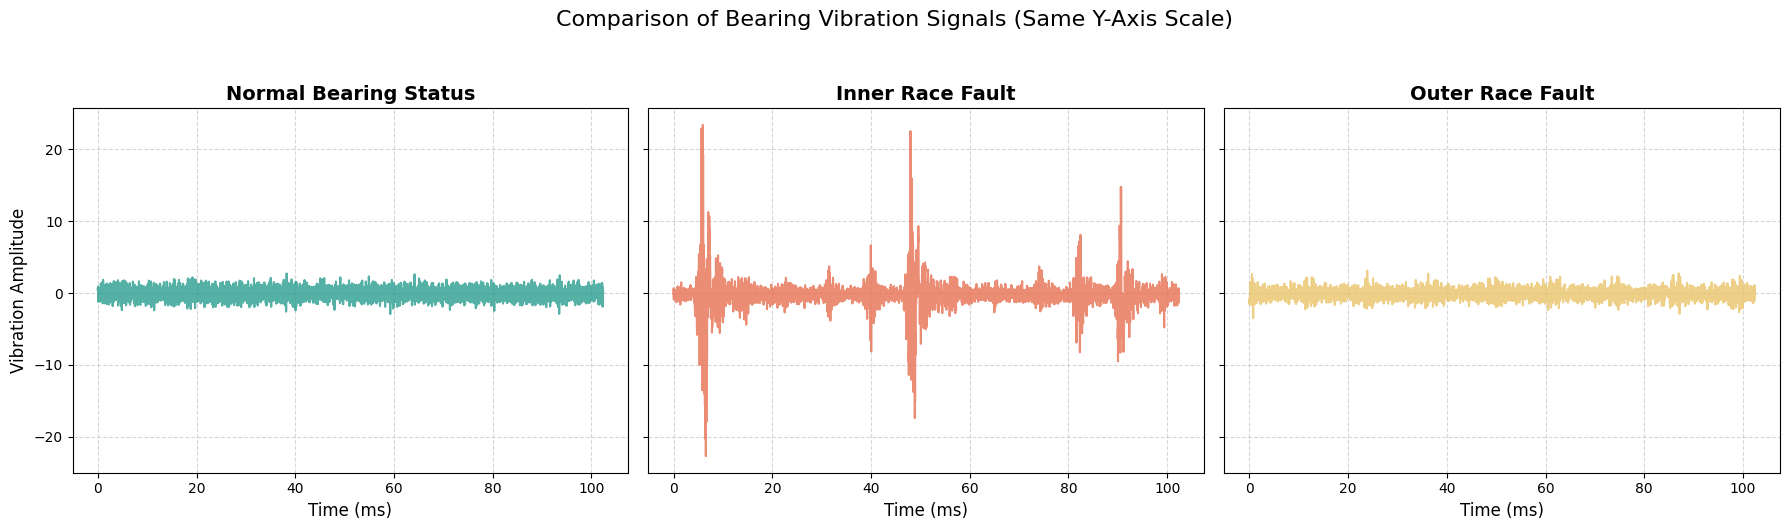

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate time axis in milliseconds
FS = 48828  # sample rate in Hz, from data/README.md
t_ms = np.arange(5000) / FS * 1000

# Find the index of the first sample of each class in the training split
idx_normal = np.where(y_train == 'Normal')[0][0]
idx_inner = np.where(y_train == 'InnerRaceFault')[0][0]
idx_outer = np.where(y_train == 'OuterRaceFault')[0][0]

# Retrieve the raw vibration data
sig_normal = X_train[idx_normal]
sig_inner = X_train[idx_inner]
sig_outer = X_train[idx_outer]

# Define colors from the kernel state
COLORS = {'Normal': '#2a9d8f', 'OuterRaceFault': '#e9c46a', 'InnerRaceFault': '#e76f51'}

# Create subplots sharing the same y-axis scale
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Normal
axes[0].plot(t_ms, sig_normal, color=COLORS['Normal'], alpha=0.8)
axes[0].set_title('Normal Bearing Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time (ms)', fontsize=12)
axes[0].set_ylabel('Vibration Amplitude', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Inner Race Fault
axes[1].plot(t_ms, sig_inner, color=COLORS['InnerRaceFault'], alpha=0.8)
axes[1].set_title('Inner Race Fault', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (ms)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Outer Race Fault
axes[2].plot(t_ms, sig_outer, color=COLORS['OuterRaceFault'], alpha=0.8)
axes[2].set_title('Outer Race Fault', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time (ms)', fontsize=12)
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Comparison of Bearing Vibration Signals (Same Y-Axis Scale)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Zoomed-In Waveform Visualization


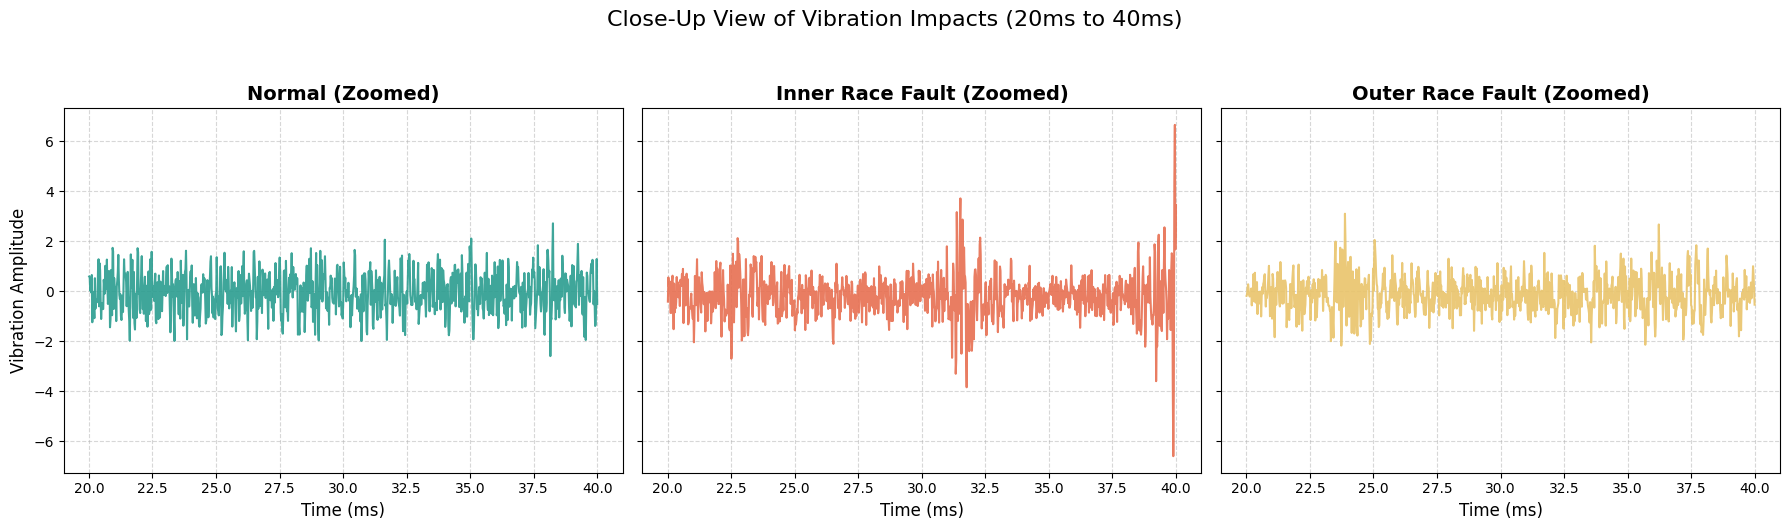

In [42]:
# Define zoom window in milliseconds
zoom_start, zoom_end = 20, 40

# Create mask for time axis
zoom_mask = (t_ms >= zoom_start) & (t_ms <= zoom_end)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Zoomed Normal
axes[0].plot(t_ms[zoom_mask], sig_normal[zoom_mask], color=COLORS['Normal'], alpha=0.9, linewidth=1.5)
axes[0].set_title('Normal (Zoomed)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time (ms)', fontsize=12)
axes[0].set_ylabel('Vibration Amplitude', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Zoomed Inner Race Fault
axes[1].plot(t_ms[zoom_mask], sig_inner[zoom_mask], color=COLORS['InnerRaceFault'], alpha=0.9, linewidth=1.5)
axes[1].set_title('Inner Race Fault (Zoomed)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (ms)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Zoomed Outer Race Fault
axes[2].plot(t_ms[zoom_mask], sig_outer[zoom_mask], color=COLORS['OuterRaceFault'], alpha=0.9, linewidth=1.5)
axes[2].set_title('Outer Race Fault (Zoomed)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time (ms)', fontsize=12)
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Close-Up View of Vibration Impacts (20ms to 40ms)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Detailed Inspection of a Single Fault Impact
locate the loudest point of a fault signal and inspect the surrounding window closely to see the sharp strike and exponential decay structure.

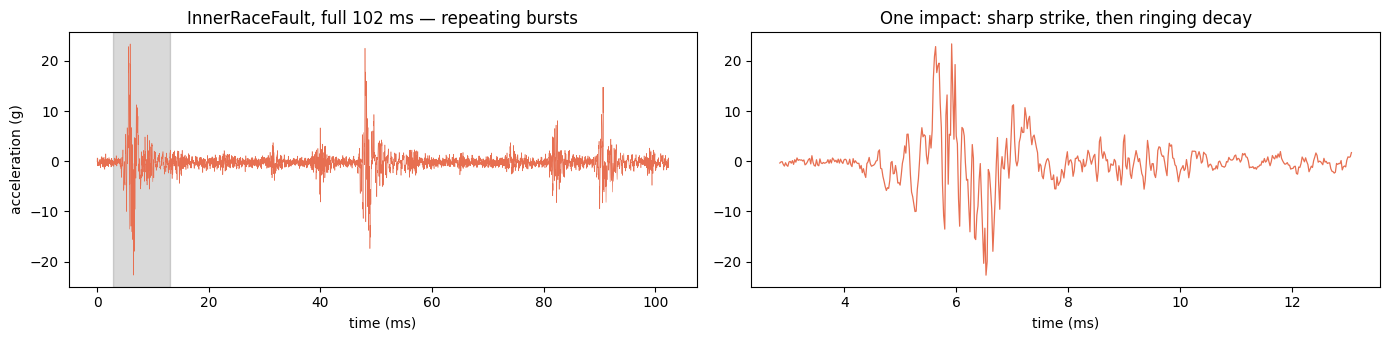

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Select an Inner Race Fault recording
segment = X_train[y_train == "InnerRaceFault"][0]

# Locate the absolute peak (loudest point of impact)
loudest = np.abs(segment).argmax()

# Define a small window around the peak
lo, hi = loudest - 150, loudest + 350

# Create two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

# Left: Full 102 ms signal showing the highlighted window of interest
axes[0].plot(t_ms, segment, lw=0.4, color=COLORS["InnerRaceFault"])
axes[0].axvspan(t_ms[lo], t_ms[hi], color="black", alpha=0.15)
axes[0].set_title("InnerRaceFault, full 102 ms — repeating bursts")

# Right: Zoomed in on a single impact
axes[1].plot(t_ms[lo:hi], segment[lo:hi], lw=0.9, color=COLORS["InnerRaceFault"])
axes[1].set_title("One impact: sharp strike, then ringing decay")

# Formatting labels
for ax in axes:
    ax.set_xlabel("time (ms)")
axes[0].set_ylabel("acceleration (g)")

plt.tight_layout()
plt.show()

---
## Part 2 — Augmentation Study

**Goal:** We only have 393 training windows, which is very little for
deep learning. We want to create realistic *synthetic* training examples
by slightly distorting real ones. The catch: the distortion must not
erase whatever makes a fault a fault. If we distort a Normal window
until it resembles a fault window, we have created a mislabeled training
example, which actively teaches the model something false.

**What this section does:**
1. Define a small set of summary metrics (a "fingerprint") for a window.
2. Implement the three candidate augmentations named in the task:
   noise injection, amplitude scaling, and time shift.
3. Check by eye and by metric whether class identity survives each one.
4. Recommend a final augmentation set with concrete parameters.


### Signal Fingerprint Function

Four numbers that summarize a vibration window:
- **RMS** — overall loudness (root mean square of the signal).
- **Peak** — the single largest absolute value.
- **Crest factor** — peak / RMS. High values mean sharp spikes relative
  to the background; this is the numeric form of the "strike then decay"
  pattern we saw in the impact anatomy plot above.
- **Kurtosis** — how heavy-tailed the distribution is. A bearing fault
  produces rare, extreme outlier values, which push kurtosis well above
  the Gaussian baseline of 0.0. (We use *excess* kurtosis, where pure
  Gaussian noise scores 0. The other common convention scores it 3 —
  they differ only by that offset.)

In [44]:
from scipy.stats import kurtosis as scipy_kurtosis

def signal_fingerprint(signal):
    """Return a dict of four summary metrics for one 1-D vibration window."""
    rms = np.sqrt(np.mean(signal ** 2))
    peak = np.abs(signal).max()
    crest = peak / rms if rms > 0 else 0.0
    kurt = float(scipy_kurtosis(signal, fisher=True))  # excess kurtosis (Gaussian = 0)
    return {"rms": rms, "peak": peak, "crest": crest, "kurtosis": kurt}


# Quick sanity check: compute fingerprints for one window of each class
for cls in ["Normal", "InnerRaceFault", "OuterRaceFault"]:
    idx = np.where(y_train == cls)[0][0]
    fp = signal_fingerprint(X_train[idx])
    print(f"{cls:20s}  RMS={fp['rms']:.4f}  Peak={fp['peak']:.4f}  "
          f"Crest={fp['crest']:.2f}  Kurtosis={fp['kurtosis']:.2f}")

Normal                RMS=0.7585  Peak=2.9227  Crest=3.85  Kurtosis=-0.09
InnerRaceFault        RMS=2.2666  Peak=23.3819  Crest=10.32  Kurtosis=30.61
OuterRaceFault        RMS=0.7095  Peak=3.5007  Crest=4.93  Kurtosis=0.66


### Augmentation Functions

Three candidate augmentations. Each takes a single 1-D signal and a
seeded random generator (`rng`) so that results are reproducible across
the entire team.

1. **Time shift** — slide the signal circularly by a random number of
   samples. A bearing fault repeats periodically; *where* in the window
   the first impact lands is arbitrary, so shifting should be harmless.
2. **Noise injection** — add Gaussian white noise at a controlled
   signal-to-noise ratio (SNR in dB). A higher SNR means *less* noise.
   Using SNR instead of a raw noise standard deviation makes the setting
   comparable across classes that have very different amplitudes.
3. **Amplitude scaling** — multiply the whole signal by a random factor
   near 1.0. This is the one we expect to be risky, because loudness is
   part of what separates the classes. Exactly *which* classes it
   endangers is something we measure rather than assume — see the
   class-overlap check further down.

In [45]:
def time_shift(signal, rng, max_shift=500):
    """Circularly shift a signal by a random amount in [-max_shift, +max_shift] samples."""
    shift = rng.integers(-max_shift, max_shift + 1)
    return np.roll(signal, shift)


def add_noise(signal, rng, snr_db=20):
    """Add Gaussian white noise at the specified signal-to-noise ratio (dB).

    Higher snr_db = less noise. 20 dB means the signal is 10x more
    powerful than the noise; 10 dB means ~3.2x more powerful.
    """
    sig_power = np.mean(signal ** 2)
    noise_power = sig_power / (10 ** (snr_db / 10))
    noise = rng.normal(0, np.sqrt(noise_power), size=signal.shape)
    return signal + noise


def scale_amplitude(signal, rng, max_pct=10):
    """Multiply the signal by a random factor in [1 - max_pct/100, 1 + max_pct/100].

    max_pct=10 means the factor is drawn from [0.90, 1.10].
    """
    lo = 1.0 - max_pct / 100.0
    hi = 1.0 + max_pct / 100.0
    factor = rng.uniform(lo, hi)
    return signal * factor


print("Augmentation functions defined.")

Augmentation functions defined.


### Visual Check — Original vs. Augmented

For each augmentation, overlay the original and augmented signal on the
same axes so we can see exactly what changed. We use a moderate
parameter setting for each.

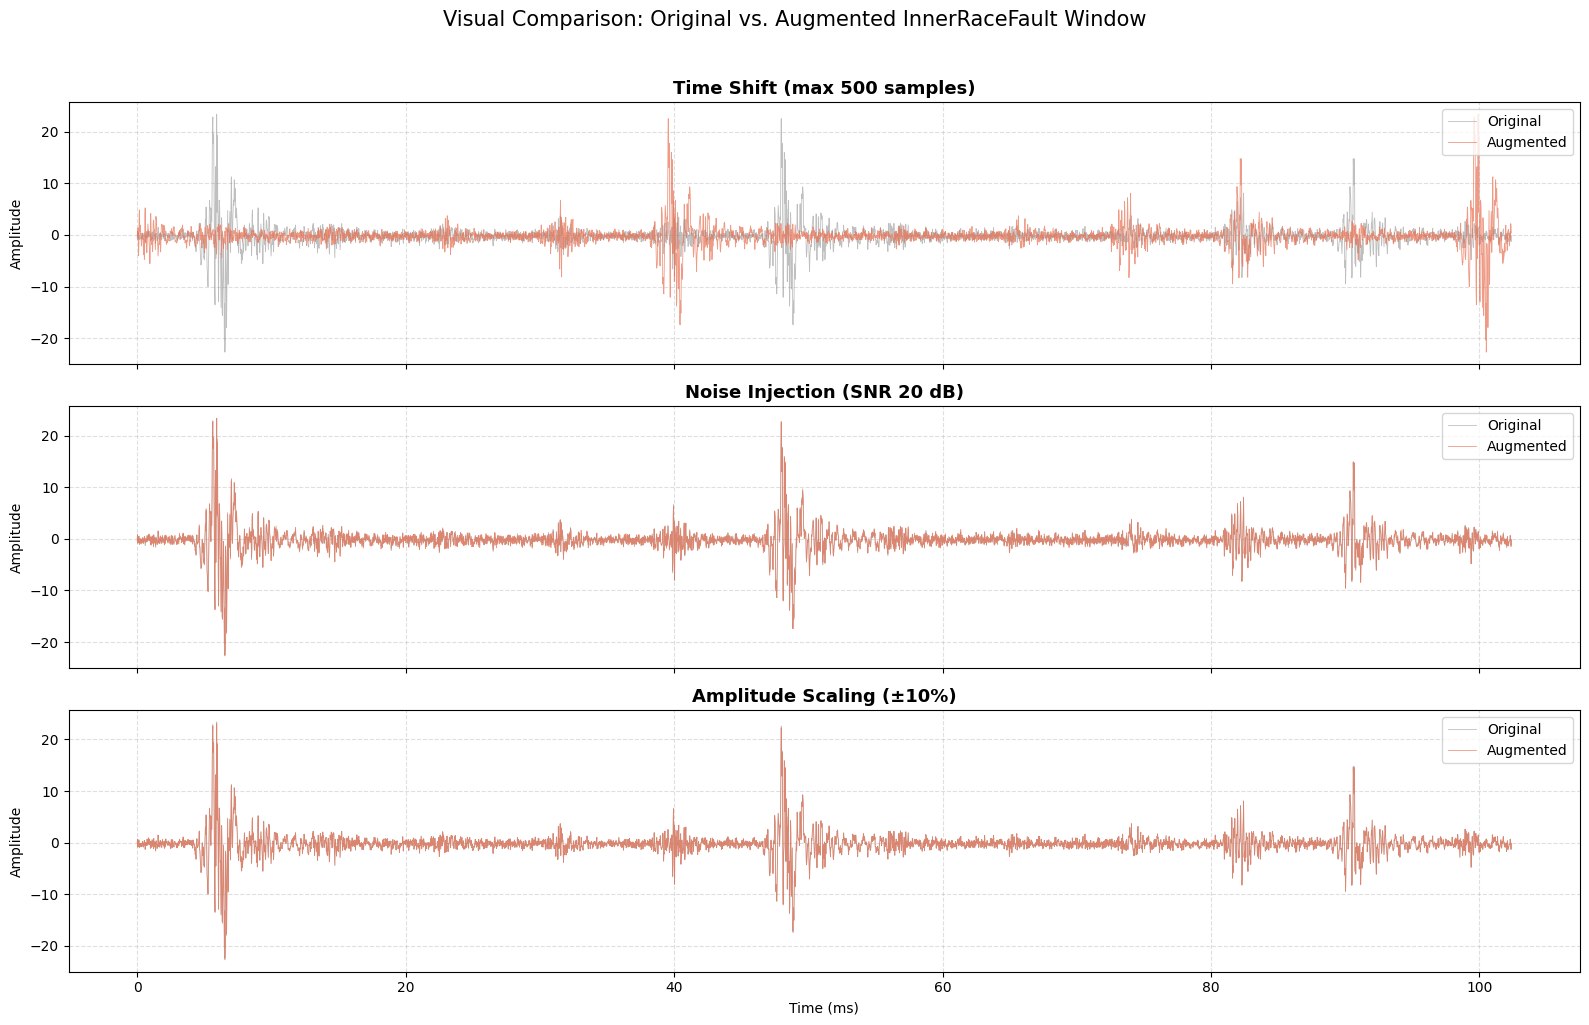

In [46]:
import matplotlib.pyplot as plt

# Pick one InnerRaceFault window — the loudest class, so changes are most visible
demo_idx = np.where(y_train == "InnerRaceFault")[0][0]
demo_signal = X_train[demo_idx]
FS = 48828
t_ms = np.arange(len(demo_signal)) / FS * 1000

rng = np.random.default_rng(42)

aug_examples = {
    "Time Shift (max 500 samples)": time_shift(demo_signal, rng, max_shift=500),
    "Noise Injection (SNR 20 dB)":  add_noise(demo_signal, rng, snr_db=20),
    "Amplitude Scaling (\u00b110%)":  scale_amplitude(demo_signal, rng, max_pct=10),
}

fig, axes = plt.subplots(len(aug_examples), 1, figsize=(16, 10), sharex=True)

for ax, (title, aug_signal) in zip(axes, aug_examples.items()):
    ax.plot(t_ms, demo_signal, color="gray", alpha=0.5, lw=0.6, label="Original")
    ax.plot(t_ms, aug_signal, color=COLORS["InnerRaceFault"], alpha=0.7, lw=0.6, label="Augmented")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Amplitude")
    ax.legend(loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.4)

axes[-1].set_xlabel("Time (ms)")
plt.suptitle("Visual Comparison: Original vs. Augmented InnerRaceFault Window",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Metric Sweep — How Much Does Each Augmentation Move the Fingerprint?

For each augmentation we sweep several strength settings across all 393
training windows and record how far each fingerprint metric moves.

**How the change is measured, and why it matters.** There are two ways to
do this, and only one of them works:

- *Wrong way:* average a metric across the class before and after, then
  compare the two averages. Amplitude scaling multiplies each window by a
  random factor centered on 1.0, so across 131 windows those factors
  average out to 1.0 and the class average barely moves — even though
  every individual window moved a lot. The averaging cancels the exact
  effect we are trying to detect.
- *Right way:* measure the change for **each window individually**, take
  the absolute value, and only then average. Nothing cancels.

We use the second method. We report both **percent change** and
**absolute change**, because percent change is misleading for kurtosis
(the Normal class has a kurtosis near zero, so dividing by it inflates
small changes into huge-looking percentages).

In [47]:
import pandas as pd

# Parameter grids for each augmentation
sweep_configs = {
    "time_shift":      {"param_name": "max_shift", "values": [100, 250, 500, 1000]},
    "add_noise":       {"param_name": "snr_db",    "values": [30, 20, 15, 10]},
    "scale_amplitude": {"param_name": "max_pct",   "values": [5, 10, 20, 30]},
}

aug_functions = {
    "time_shift":      time_shift,
    "add_noise":       add_noise,
    "scale_amplitude": scale_amplitude,
}

classes = np.unique(y_train)
metric_names = ["rms", "peak", "crest", "kurtosis"]

# Fingerprint every training window once, before any augmentation
baseline_fps = np.array([
    [signal_fingerprint(X_train[i])[m] for m in metric_names]
    for i in range(len(X_train))
])  # shape: (393, 4)

rows = []

for aug_name, config in sweep_configs.items():
    aug_fn = aug_functions[aug_name]

    for param_val in config["values"]:
        rng_sweep = np.random.default_rng(SEED)

        # Apply this augmentation setting to every training window
        aug_fps = np.empty_like(baseline_fps)
        for i in range(len(X_train)):
            aug_signal = aug_fn(X_train[i], rng_sweep, **{config["param_name"]: param_val})
            fp = signal_fingerprint(aug_signal)
            aug_fps[i] = [fp[m] for m in metric_names]

        for cls in classes:
            mask = y_train == cls

            for j, metric in enumerate(metric_names):
                before = baseline_fps[mask, j]
                after = aug_fps[mask, j]

                # Per-window change first, THEN average.
                change_per_window = np.abs(after - before)

                abs_change = change_per_window.mean()

                # Guard the denominator: Normal's kurtosis sits near zero
                safe_denominator = np.where(np.abs(before) > 1e-12, np.abs(before), 1.0)
                pct_change = np.mean(change_per_window / safe_denominator) * 100

                rows.append({
                    "augmentation": aug_name,
                    "param": f"{config['param_name']}={param_val}",
                    "class": cls,
                    "metric": metric,
                    "baseline_mean": round(before.mean(), 4),
                    "abs_change": round(abs_change, 4),
                    "pct_change": round(pct_change, 2),
                })

sweep_df = pd.DataFrame(rows)

# Keep table rows in sweep order rather than alphabetical order.
# Without this, "max_shift=1000" sorts between "100" and "250", which
# makes the strength trend impossible to read.
param_order = [
    f"{cfg['param_name']}={v}"
    for cfg in sweep_configs.values()
    for v in cfg["values"]
]
sweep_df["param"] = pd.Categorical(sweep_df["param"], categories=param_order, ordered=True)

print(f"Sweep complete: {len(sweep_df)} rows")
sweep_df.head(12)

Sweep complete: 144 rows


,augmentation,param,class,metric,baseline_mean,abs_change,pct_change
0,time_shift,max_shift=100,InnerRaceFault,rms,1.8861,0.0,0.0
1,time_shift,max_shift=100,InnerRaceFault,peak,22.4538,0.0,0.0
2,time_shift,max_shift=100,InnerRaceFault,crest,11.9077,0.0,0.0
3,time_shift,max_shift=100,InnerRaceFault,kurtosis,31.7817,0.0,0.0
4,time_shift,max_shift=100,Normal,rms,0.7771,0.0,0.0
5,time_shift,max_shift=100,Normal,peak,3.0330,0.0,0.0
6,time_shift,max_shift=100,Normal,crest,3.9040,0.0,0.0
7,time_shift,max_shift=100,Normal,kurtosis,0.0223,0.0,0.0
8,time_shift,max_shift=100,OuterRaceFault,rms,0.8821,0.0,0.0
9,time_shift,max_shift=100,OuterRaceFault,peak,5.4103,0.0,0.0


#### Percent Change by Augmentation and Metric

Averaged across all three classes.

In [48]:
pct_table = (
    sweep_df
    .groupby(["augmentation", "param", "metric"], observed=True)["pct_change"]
    .mean()
    .unstack("metric")[metric_names]
    .round(2)
)
print("Mean per-window % change:")
pct_table

Mean per-window % change:


metric                            rms   peak  crest  kurtosis
augmentation    param                                        
add_noise       snr_db=30        0.06   0.42   0.41     14.55
                snr_db=20        0.50   1.30   1.29     46.15
                snr_db=15        1.57   2.27   2.33     80.63
                snr_db=10        4.89   4.09   4.39    135.79
scale_amplitude max_pct=5        2.48   2.48   0.00      0.00
                max_pct=10       4.96   4.96   0.00      0.00
                max_pct=20       9.93   9.93   0.00      0.00
                max_pct=30      14.89  14.89   0.00      0.00
time_shift      max_shift=100    0.00   0.00   0.00      0.00
                max_shift=250    0.00   0.00   0.00      0.00
                max_shift=500    0.00   0.00   0.00      0.00
                max_shift=1000   0.00   0.00   0.00      0.00

**Reading it:**

- **Time shift** is 0.00% on every metric at every setting. That is
  guaranteed, not luck — RMS, peak, crest, and kurtosis do not depend on
  the *order* of the samples, so sliding the window cannot change them.
- **Amplitude scaling** moves RMS and peak by almost exactly half the
  parameter (±30% gives ~14.9%), which is the textbook expectation for a
  uniform random factor. It leaves crest and kurtosis at exactly 0.00%,
  because both are ratios that cancel out scale. That clean split is a
  good sign the measurement is behaving correctly.
- **Noise injection** shows a huge kurtosis percentage. Do not trust that
  number on its own — the next table explains why.

#### Absolute Change — Needed Because Kurtosis Percentages Lie

The Normal class has an average kurtosis of about **0.02**, essentially
zero. Dividing any change by 0.02 produces an enormous percentage even
when the actual movement is negligible. The table below shows the raw
absolute change in kurtosis per class, next to each class's baseline, so
the numbers can be judged against how far apart the classes actually are.

In [49]:
kurt = sweep_df[sweep_df["metric"] == "kurtosis"]

kurt_abs = (
    kurt.pivot_table(index=["augmentation", "param"], columns="class",
                     values="abs_change", observed=True)
    .round(3)
)

print("Baseline kurtosis by class (how far apart the classes start):")
for cls in ["Normal", "OuterRaceFault", "InnerRaceFault"]:
    baseline = kurt[kurt["class"] == cls]["baseline_mean"].iloc[0]
    print(f"  {cls:16s} {baseline:8.3f}")

print("\nAbsolute kurtosis change caused by each augmentation:")
kurt_abs

Baseline kurtosis by class (how far apart the classes start):
  Normal              0.022
  OuterRaceFault      2.883
  InnerRaceFault     31.782

Absolute kurtosis change caused by each augmentation:


class                           InnerRaceFault  Normal  OuterRaceFault
augmentation    param                                                 
add_noise       snr_db=30                0.080   0.003           0.012
                snr_db=20                0.617   0.011           0.061
                snr_db=15                1.910   0.019           0.178
                snr_db=10                5.527   0.034           0.508
scale_amplitude max_pct=5                0.000   0.000           0.000
                max_pct=10               0.000   0.000           0.000
                max_pct=20               0.000   0.000           0.000
                max_pct=30               0.000   0.000           0.000
time_shift      max_shift=100            0.000   0.000           0.000
                max_shift=250            0.000   0.000           0.000
                max_shift=500            0.000   0.000           0.000
                max_shift=1000           0.000   0.000           0.000

**Reading it:** at `snr_db=20` the absolute kurtosis shift is about 0.01
for Normal, 0.06 for OuterRaceFault, and 0.62 for InnerRaceFault. Against
baselines of 0.02, 2.88, and 31.78, those are small — roughly 2% for both
fault classes. The classes stay comfortably separated, so 20 dB noise is
safe despite the alarming percentage in the previous table.

At `snr_db=10` the InnerRaceFault shift grows to about 5.5, which is
around 17% of its baseline. That is real erosion of the impulsiveness
signal, which is why 10 dB is not acceptable.

#### Per-Class Detail for Amplitude Scaling

Now that the measurement is per-window, we can see how much scaling
actually moves each class.

In [50]:
scale_detail = sweep_df[sweep_df["augmentation"] == "scale_amplitude"]

scale_pivot = (
    scale_detail
    .pivot_table(index=["param", "class"], columns="metric",
                 values="pct_change", observed=True)[metric_names]
    .round(2)
)
print("Amplitude scaling — per-window % change by class and strength:")
scale_pivot

Amplitude scaling — per-window % change by class and strength:


metric                       rms   peak  crest  kurtosis
param      class                                        
max_pct=5  InnerRaceFault   2.37   2.37    0.0       0.0
           Normal           2.50   2.50    0.0       0.0
           OuterRaceFault   2.58   2.58    0.0       0.0
max_pct=10 InnerRaceFault   4.74   4.74    0.0       0.0
           Normal           5.00   5.00    0.0       0.0
           OuterRaceFault   5.15   5.15    0.0       0.0
max_pct=20 InnerRaceFault   9.49   9.49    0.0       0.0
           Normal           9.99   9.99    0.0       0.0
           OuterRaceFault  10.31  10.31    0.0       0.0
max_pct=30 InnerRaceFault  14.23  14.23    0.0       0.0
           Normal          14.99  14.99    0.0       0.0
           OuterRaceFault  15.46  15.46    0.0       0.0

---
### Class-Overlap Check — Does Scaling Actually Blur the Classes?

Percent change tells us a metric *moved*, but not whether the move was
harmful. What actually matters is whether two classes start to **overlap**.

The test below measures overlap directly: for every Normal window paired
against every OuterRaceFault window, what fraction of those pairs have
the Normal window louder than the fault window? If augmentation drives
that number up, the two classes are becoming harder to tell apart.

We check all three class pairs so we can see *which* pair is actually
fragile, rather than assuming.

In [51]:
def pair_overlap(values_low, values_high):
    """Fraction of cross-class pairs where the quieter class is louder.

    0.0 means perfect separation. 0.5 means the two classes are
    indistinguishable on this metric.
    """
    return np.mean(values_low[:, None] > values_high[None, :])


# Raw per-window RMS for every training signal
rms_all = np.sqrt(np.mean(X_train ** 2, axis=1))

print("Per-window RMS by class (raw, no augmentation):")
for cls in ["Normal", "OuterRaceFault", "InnerRaceFault"]:
    v = rms_all[y_train == cls]
    print(f"  {cls:16s} median={np.median(v):.4f}   "
          f"range = {v.min():.4f} to {v.max():.4f}")

overlap_rows = []

for pct in [0, 5, 10, 20, 30]:
    rng_ov = np.random.default_rng(0)
    if pct == 0:
        scaled = rms_all.copy()
    else:
        factors = rng_ov.uniform(1 - pct / 100, 1 + pct / 100, size=rms_all.shape)
        scaled = rms_all * factors

    normal = scaled[y_train == "Normal"]
    outer  = scaled[y_train == "OuterRaceFault"]
    inner  = scaled[y_train == "InnerRaceFault"]

    overlap_rows.append({
        "scaling": f"+/-{pct}%",
        "Normal vs Outer": round(pair_overlap(normal, outer) * 100, 1),
        "Outer vs Inner":  round(pair_overlap(outer, inner) * 100, 1),
        "Normal vs Inner": round(pair_overlap(normal, inner) * 100, 1),
    })

overlap_df = pd.DataFrame(overlap_rows)
print("\nClass overlap (% of cross-class pairs that are inverted):")
overlap_df

Per-window RMS by class (raw, no augmentation):
  Normal           median=0.7784   range = 0.7332 to 0.8363
  OuterRaceFault   median=0.8937   range = 0.5790 to 1.6649
  InnerRaceFault   median=1.8736   range = 1.4674 to 2.4345

Class overlap (% of cross-class pairs that are inverted):


,scaling,Normal vs Outer,Outer vs Inner,Normal vs Inner
0,+/-0%,31.2,0.6,0.0
1,+/-5%,31.1,0.7,0.0
2,+/-10%,32.6,0.9,0.0
3,+/-20%,37.4,1.6,0.0
4,+/-30%,39.4,2.5,0.0


**Reading the result:** Normal vs InnerRaceFault stays at 0% overlap even
at the most aggressive setting. Those two classes sit about 2.4x apart in
RMS, so amplitude scaling cannot realistically collide them.

The fragile pair is **Normal vs OuterRaceFault**, whose medians differ by
only about 15%. They already overlap substantially with no augmentation at
all, and scaling makes it measurably worse. Any augmentation that moves
amplitude is therefore attacking the class boundary that was already the
weakest one.

---
## Augmentation Recommendation

### Approved

**Time shift**  `max_shift=500` samples, circular roll

All four fingerprint metrics change by exactly 0.00% at every setting tested. This is guaranteed rather than lucky: RMS, peak, crest, and kurtosis ignore the order of samples, so a circular roll cannot affect them. Class overlap is unchanged. The safest augmentation available.

**Noise injection**  `snr_db=20` — treat 20 dB as a **floor**

RMS moves 0.50%, peak 1.30%, crest 1.29%. Kurtosis shows a large *percentage* only because the Normal class baseline is near zero; in absolute terms it shifts 0.01 (Normal), 0.06 (Outer), and 0.62 (Inner) against baselines of 0.02, 2.88, and 31.78 — about 2% for both fault classes. Class separation holds. At 10 dB the InnerRaceFault shift grows to ~5.5, roughly 17% of baseline, which does erode the impulsiveness signal. Hence 20 dB is a floor, not a target.



### Rejected


**Amplitude scaling**  

Loudness is part of what separates the classes, so scaling attacks the signal we most need to keep. Per window it moves RMS and peak by half the parameter setting (±30% gives ~14.9%). Normal and OuterRaceFault medians differ by only ~15% in RMS and already overlap ~31% with no augmentation at all; at ±30% that rises to ~39%. The cost lands squarely on the class boundary that was already weakest. Time shift and noise injection supply enough variety, so there is no reason to accept it. If ever required, cap at ±5%.


